<a href="https://colab.research.google.com/github/Sulayman98/MSc-Data-Science-Project-2/blob/main/Data_Science_Project_2_for%20submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **1.0 Introduction**

Returns in the stock market can be a means to accumulate wealth, providing an additional income source to wages. Given the importance of the stock market, this project aims to provide insights for both industry players and individuals who are aiming to build wealth through the Malaysian stock market.

To this end, the project will to look compare the returns across the overall Malaysian stock market (KLSE) against cyclical sectors such as the financial (KLFIN) and technology (KLTE) industries as well non-cyclical sectors represented by KLCM, which reflects consumer staples.

Additionally, the project aims to provide an understanding of these indices' performances during times of high uncertainty, reflected by the Volatility Index (VIX). The objective is to provide a general rule of thumb on which index performs relatively well during crisis episodes and underlying reasons supporting this performance.

Throughout this project, insights will be gathered by using descriptive statistics and visualisations.

# **2.0 Data Collection and Data Wrangling**

Datasets were obtained from open source Investing.com for KLSE and VIX data. This includes cyclical sub-indices such as KLTE (KL Technology Index) and KLFIN (KL Finance Index) as well as defensive sub-indices such as KLCM (KL Consumer Product)

#Links to dataset

1. KLSE https://www.investing.com/indices/ftse-malaysia-klci-historical-data
2. KLFIN https://www.investing.com/indices/kl-finance-historical-data
3. KLTE https://www.investing.com/indices/kl-technology
4. KLCM https://www.investing.com/indices/kl-consumer-product-historical-data
5. VIX https://www.investing.com/indices/volatility-s-p-500-historical-data

#General description of the dataset

1. KLSE: the benchmark index of Bursa Malaysia, tracking the 30 largest companies by market capitalization listed on the exchange. It serves as the primary gauge of overall Malaysian stock market performance and investor sentiment toward the broader economy.

2. KLFIN: tracks Malaysian banking and financial services companies. As a cyclical sector, its performance is closely tied to the domestic economic cycle, interest rate environment, and credit conditions Banks tend to do well in expansions and are negatively affected during downturns due to rising defaults and shrinking loan demand.

3. KLTE: tracks Malaysian-listed technology sector companies, including semiconductor manufacturers, electronics, and tech hardware firms. As a cyclical sector heavily exposed to global supply chains and export demand, it tends to be more volatile and sensitive to global economic conditions

4. KLCM: tracks companies producing essential goods and services (food, beverages, household products, retail). As a defensive sector, demand tends to remain relatively stable regardless of the broader economic cycle, since consumers continue purchasing necessities even during downturns

5. VIX: a measure of expected 30-day volatility in the US S&P 500 derived from options pricing, often called the "fear gauge." While US-focused, it's widely used as a proxy for global risk sentiment, since spikes in VIX typically coincide with broad risk-off behavior across global markets, including emerging markets like Malaysia

In [5]:
#Part 1  Loading the dataset

import pandas as pd
from datetime import datetime
from google.colab import files
drive.mount('/content/drive')

dataframe= {
    "klse": pd.read_csv("/content/drive/MyDrive/STQD6014 Data Science Project 2 Datasets/FTSE Malaysia KLCI Historical Data.csv"),
    "klfin": pd.read_csv("/content/drive/MyDrive/STQD6014 Data Science Project 2 Datasets/KL Finance Historical Data.csv"),
    "klte": pd.read_csv("/content/drive/MyDrive/STQD6014 Data Science Project 2 Datasets/KL Technology Historical Data.csv"),
    "klcm": pd.read_csv("/content/drive/MyDrive/STQD6014 Data Science Project 2 Datasets/KL Consumer Product Historical Data.csv"),
    "vix": pd.read_csv("/content/drive/MyDrive/STQD6014 Data Science Project 2 Datasets/CBOE Volatility Index Historical Data.csv")
}
dataframe["klse"].head() #Testing if the dataset can be loaded


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Date,Price,Open,High,Low,Vol.,Change %
0,06/01/2026,"1,683.63","1,688.18","1,698.53","1,672.74",5.21B,0.03%
1,05/01/2026,"1,683.07","1,728.74","1,768.46","1,680.59",6.12B,-2.26%
2,04/01/2026,"1,722.02","1,715.94","1,733.84","1,673.14",5.84B,1.87%
3,03/01/2026,"1,690.36","1,688.64","1,737.12","1,664.07",6.98B,-1.53%
4,02/01/2026,"1,716.61","1,756.09","1,761.57","1,714.09",4.65B,-1.39%


# 2.1 Understanding the data structure

Within this dataframe, for each of the variables klse, klfin, klte, klcm and vix, there are 258 rows which represents the monthly data from January 2005 until June 2026, and 7 columns containing:

1. Date: The month of trading
2. Price: The closing price for the month
3. Open: Opening price for the month
4. High: Highest price during the month
5. Low: Lowest price during the month
6. Volume: Number of shares traded during the month
7. Change %: Percentage share from previous month's closing position

Some of these data are classified as objects. For analysis preparation, they will be wrangled into 'float'.

In [6]:
# Structure of the dataframes
for name, df in dataframe.items():
    print(f"=== {name} ===")
    print(df.info())
    print()

=== klse ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      258 non-null    object
 1   Price     258 non-null    object
 2   Open      258 non-null    object
 3   High      258 non-null    object
 4   Low       258 non-null    object
 5   Vol.      258 non-null    object
 6   Change %  258 non-null    object
dtypes: object(7)
memory usage: 14.2+ KB
None

=== klfin ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      258 non-null    object
 1   Price     258 non-null    object
 2   Open      258 non-null    object
 3   High      258 non-null    object
 4   Low       258 non-null    object
 5   Vol.      258 non-null    object
 6   Change %  258 non-null    object
dtypes: object(7)
memory usage: 14

In [7]:
#Identifying number of rows and columns in dataframe
print('The number of rows and columns in dataframe:', df.info)

The number of rows and columns in dataframe: <bound method DataFrame.info of            Date  Price   Open   High    Low  Vol. Change %
0    06/01/2026  18.81  15.88  23.34  15.18   NaN   22.78%
1    05/01/2026  15.32  17.01  19.44  15.22   NaN   -9.30%
2    04/01/2026  16.89  24.30  28.00  16.87   NaN  -33.11%
3    03/01/2026  25.25  24.66  35.30  20.28   NaN   27.14%
4    02/01/2026  19.86  19.95  23.10  16.05   NaN   13.88%
..          ...    ...    ...    ...    ...   ...      ...
253  05/01/2005  13.29  15.45  17.70  11.65   NaN  -13.19%
254  04/01/2005  15.31  13.64  18.59  11.20   NaN    9.20%
255  03/01/2005  14.02  11.95  14.89  11.66   NaN   16.06%
256  02/01/2005  12.08  12.80  13.20  10.90   NaN   -5.77%
257  01/01/2005  12.82  13.39  14.75  12.29   NaN   -3.54%

[258 rows x 7 columns]>


# 2.2 Cleaning the data

In [8]:
dataframe["klse"].head()

,Date,Price,Open,High,Low,Vol.,Change %
0,06/01/2026,"1,683.63","1,688.18","1,698.53","1,672.74",5.21B,0.03%
1,05/01/2026,"1,683.07","1,728.74","1,768.46","1,680.59",6.12B,-2.26%
2,04/01/2026,"1,722.02","1,715.94","1,733.84","1,673.14",5.84B,1.87%
3,03/01/2026,"1,690.36","1,688.64","1,737.12","1,664.07",6.98B,-1.53%
4,02/01/2026,"1,716.61","1,756.09","1,761.57","1,714.09",4.65B,-1.39%


In [9]:
dataframe["klfin"].head()

,Date,Price,Open,High,Low,Vol.,Change %
0,06/01/2026,"19,644.36","19,600.37","19,841.40","19,321.03",1.25B,0.61%
1,05/01/2026,"19,524.29","19,936.86","20,597.81","19,486.00",1.59B,-1.81%
2,04/01/2026,"19,885.03","20,318.16","20,545.36","19,489.26",1.67B,-0.69%
3,03/01/2026,"20,023.99","20,715.43","21,058.58","19,765.68",2.31B,-5.02%
4,02/01/2026,"21,081.80","21,604.45","21,924.71","21,058.15",2.01B,-1.99%


In [10]:
dataframe["klte"].head()

,Date,Price,Open,High,Low,Vol.,Change %
0,06/01/2026,71.48,73.12,74.67,69.29,4.72B,-3.24%
1,05/01/2026,73.87,62.56,73.87,62.56,6.73B,18.99%
2,04/01/2026,62.08,51.56,64.56,50.98,5.85B,22.91%
3,03/01/2026,50.51,54.32,55.31,50.21,3.74B,-9.59%
4,02/01/2026,55.87,56.26,57.01,52.72,3.84B,-0.64%


In [11]:
dataframe["vix"].head()

,Date,Price,Open,High,Low,Vol.,Change %
0,06/01/2026,18.81,15.88,23.34,15.18,NaN,22.78%
1,05/01/2026,15.32,17.01,19.44,15.22,NaN,-9.30%
2,04/01/2026,16.89,24.30,28.00,16.87,NaN,-33.11%
3,03/01/2026,25.25,24.66,35.30,20.28,NaN,27.14%
4,02/01/2026,19.86,19.95,23.10,16.05,NaN,13.88%


# 2.2.1 Cleaning and wrangling the data

Step 1: Identifying variables that are needed for cleaning and wrangling

klse, klfin, klte and klcp have the letter 'B' denoting billions and comma in their price, open, high and low. For analysis purposes, this would need to be cleaned and wrangled into the proper format.

The volume for vix is denoted by NaN, given that this index is not traded but rather tracks the overall sentiments. For analysis, this would also need to be included in the cleaning process.

In [12]:
def clean_df(df):
    df['Date'] = pd.to_datetime(df['Date'])

    # Removing commas ','
    for col in ['Price', 'Open', 'High', 'Low']:
        df[col] = df[col].astype(str).str.replace(',', '').astype(float)

    #Removing %
    df['Change %'] = df['Change %'].astype(str).str.replace('%', '').astype(float)

    # To standardise the volume data set which has B in it with e9, denoting the number of zeros in billions
    df['Vol.'] = df['Vol.'].astype(str).str.replace('B', 'e9')
    df['Vol.'] = pd.to_numeric(df['Vol.'], errors='coerce')
    df = df.sort_values('Date').reset_index(drop=True)
    return df

for name in dataframe:
    dataframe[name] = clean_df(dataframe[name])

dataframe["klse"].info() # Checking the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      258 non-null    datetime64[ns]
 1   Price     258 non-null    float64       
 2   Open      258 non-null    float64       
 3   High      258 non-null    float64       
 4   Low       258 non-null    float64       
 5   Vol.      258 non-null    float64       
 6   Change %  258 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 14.2 KB


## 2.2.2 Choosing the necessary data for analysis

Given the objective is to understand the behaviour of returns in the stock market indices and their relationship with sentiments proxied by VIX, the project will focus specifically on understanding the price movements. Hence, a new dataframe 'combined' contains only the dates and prices for the indices and vix

In [13]:
#Choosing necessary data for analysis

combined = pd.DataFrame()

for name, df in dataframe.items():
    temp = df[['Date', 'Price']].copy()
    temp = temp.rename(columns={'Price': f'{name}_price'})
    if combined.empty:
        combined = temp
    else:
        combined = combined.merge(temp, on='Date', how='inner')


## 2.3 Statistical summaries, description and exploratory graph analysis

As mentioned earlier, all datasets contain series from Jan 2005 until June 2026. From these datasets, the mean and standard deviation of the major indices and vix were extracted to provide a general overview. Several observations were observed from these summaries. First, apart from KLTE and VIX, most indices have high standard deviation from the mean, which can also observed from the minimum and maximum ranges. For example, KLSE's mean is 1492, with minimum 860.7 and maximum value of 1882.7.

To understand this futher, a line chart was plotted for all the four indices and vix to study the long term trend. For KLSE, KLFIN, KLTE and KLCM, these variables trend upwards over the years with some volatility, suggesting non-stationarity i.e it does not revert to a single mean. Vix, on the other hand, shows the properties of mean reversion from the graph and from the relatively low standard deviation.

Key observations from the graphs include:

1. Upward trend suggesting investors who invests in these indices will gain a profit over the long-run.
2. The mean reversion properties of the Vix suggests uncertainties taper over time.

Additionally, while all indices shows a long-term upward trend, for the technology index KLTE, the trend became pronounced in 2020 and have stabilised in the following years. This will be studied further in the next section.


In [14]:
#Statistical summary of the data
for name, df in combined.items():
    print(f"=== {name} ===")
    print(df.describe())
    print()

#Extracting just the mean and standard deviation of prices in the major indices and vix
print(combined.describe().loc[['mean', 'std']])

=== Date ===
count                              258
mean     2015-09-16 03:37:40.465116160
min                2005-01-01 00:00:00
25%                2010-05-08 18:00:00
50%                2015-09-16 00:00:00
75%                2021-01-24 06:00:00
max                2026-06-01 00:00:00
Name: Date, dtype: object

=== klse_price ===
count     258.000000
mean     1492.016395
std       270.777150
min       860.730000
25%      1379.290000
50%      1564.555000
75%      1676.812500
max      1882.710000
Name: klse_price, dtype: float64

=== klfin_price ===
count      258.000000
mean     14142.723953
std       3554.717220
min       6541.580000
25%      11903.700000
50%      15018.070000
75%      16683.870000
max      21510.180000
Name: klfin_price, dtype: float64

=== klte_price ===
count    258.000000
mean      35.830581
std       21.462540
min       11.140000
25%       18.775000
50%       28.475000
75%       52.202500
max       99.380000
Name: klte_price, dtype: float64

=== klcm_price ===
cou

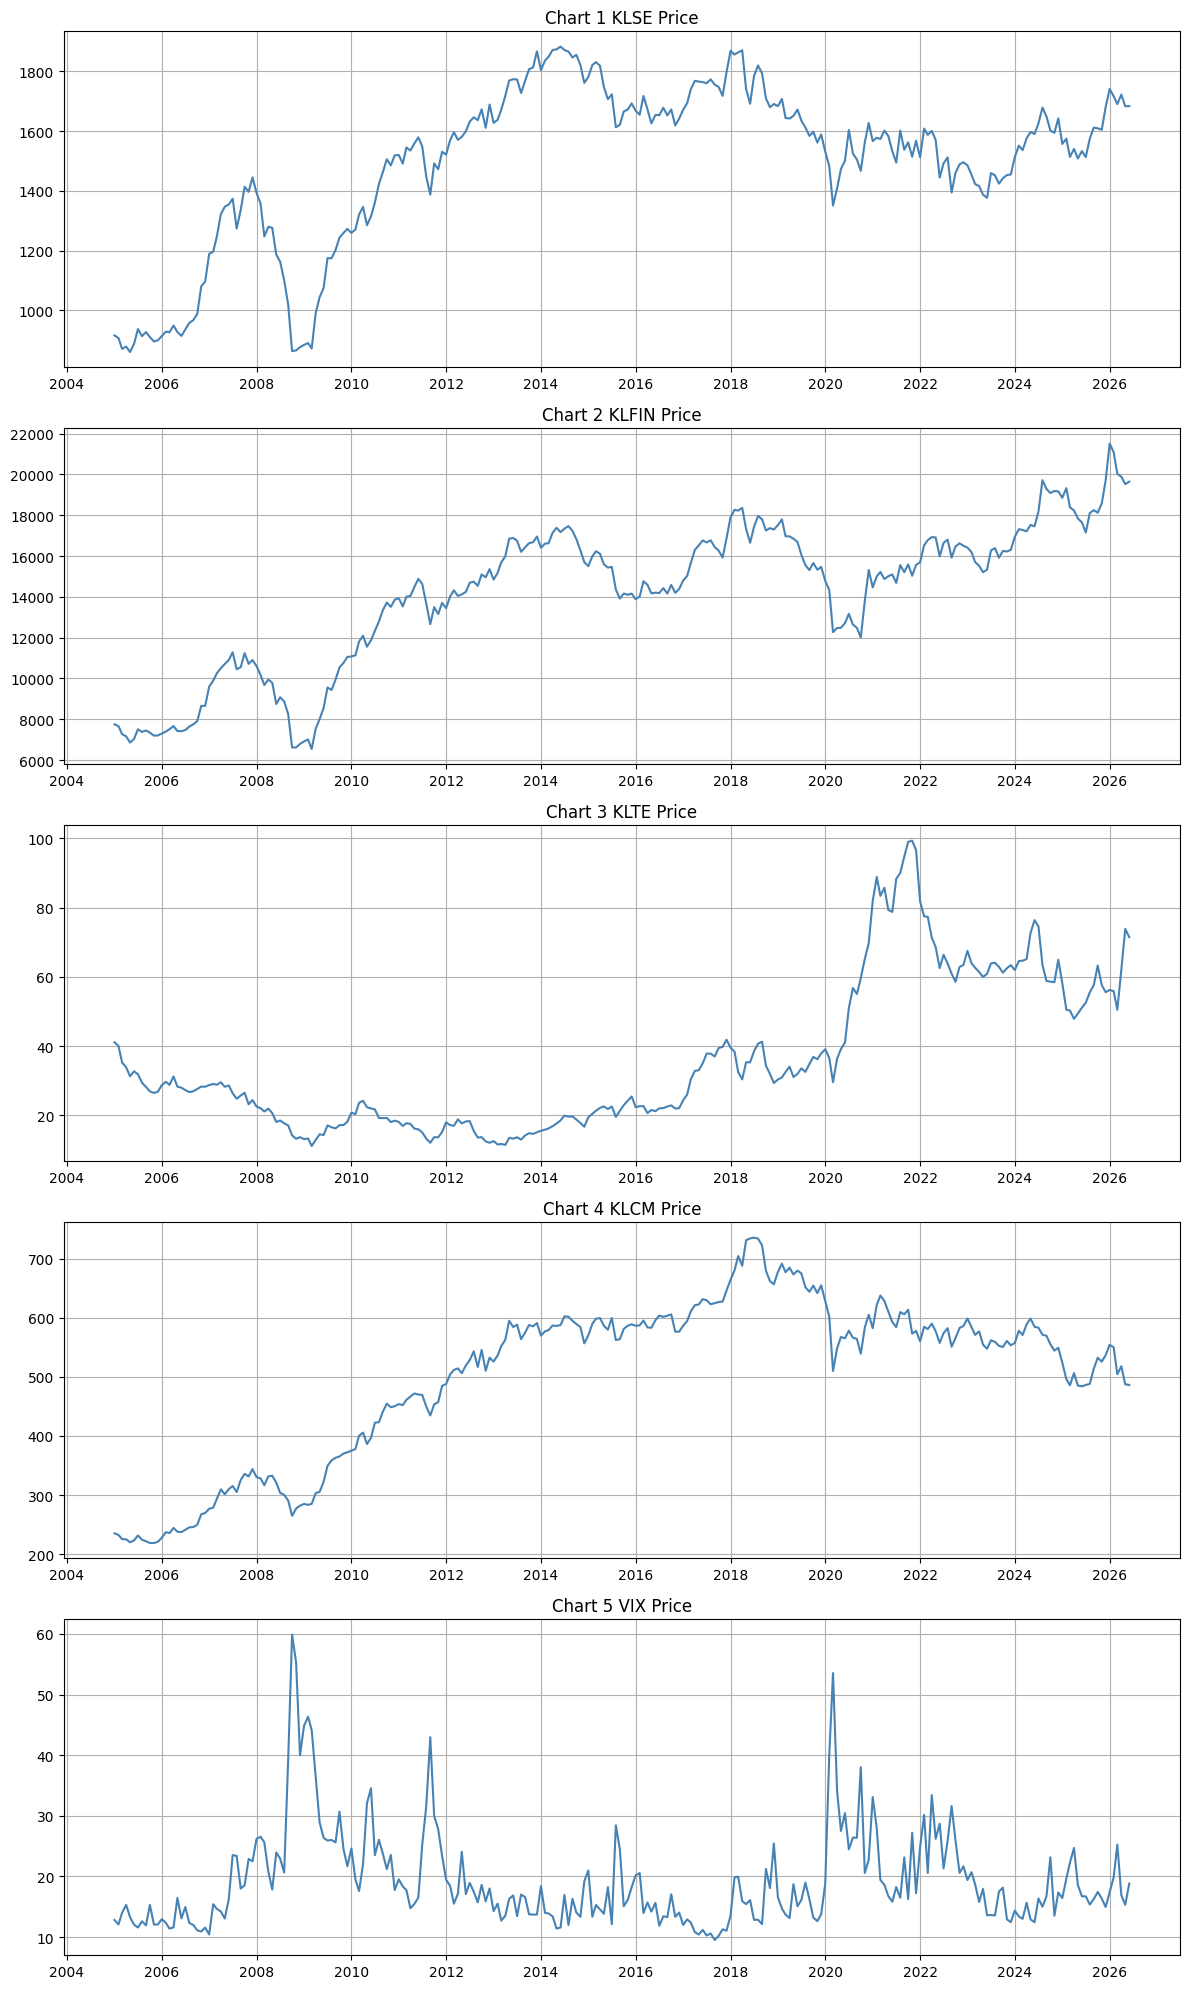

In [15]:
# Investigating the large standard deviation in prices

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

names = list(dataframe.keys())  # klse, klfin, klte, klcm, vix

fig, axes = plt.subplots(len(names), 1, figsize=(12, 4*len(names)))

for i, name in enumerate(names):
    axes[i].plot(combined['Date'], combined[f'{name}_price'], color='steelblue')
    axes[i].set_title(f"Chart {i+1} {name.upper()} Price")
    axes[i].xaxis.set_major_locator(mdates.YearLocator(2))
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [16]:
# Confirming apart from VIX, the others are non-stationary
from statsmodels.tsa.stattools import adfuller

for name in dataframe.keys():
    series = combined[f'{name}_price'].dropna()
    result = adfuller(series)
    print(f"{name.upper()} - ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}")
    if result[1] > 0.05:
        print(f"  -> {name.upper()} price series is likely NON-stationary\n")
    else:
        print(f"  -> {name.upper()} price series is likely stationary\n")

KLSE - ADF Statistic: -2.1222, p-value: 0.2357
  -> KLSE price series is likely NON-stationary

KLFIN - ADF Statistic: -1.4730, p-value: 0.5468
  -> KLFIN price series is likely NON-stationary

KLTE - ADF Statistic: -1.1429, p-value: 0.6977
  -> KLTE price series is likely NON-stationary

KLCM - ADF Statistic: -1.9534, p-value: 0.3074
  -> KLCM price series is likely NON-stationary

VIX - ADF Statistic: -5.4916, p-value: 0.0000
  -> VIX price series is likely stationary



## 2.4 Comparing investment performances across indices

In section 2.3, it was established that over the long-run, all indices trend upward and can provide a profit to the investor. However, comparing indices based on price levels alone may be inaccurate as indices trade at vastly different levels, making direct comparisons of volatility or returns on a like-for-like basis impossible. For instance, a 10-point move in KLSE carries a very different meaning compared to the same move in KLTE. To address this, month-on-month percentage changes are used, which express each index's movement on a common scale regardless of their absolute price levels. In the dataset, this is represented by the Change, % variable, which captures how much each index moved relative to the previous month.

Beyond comparability, this transformation also resolves a statistical concern. Price levels, as observed in section 2.3, are non-stationary i.e. they trend upward over time and do not revert to a stable mean, making their statistical properties unreliable for analysis. By taking month-on-month percentage changes, this drift is removed. This is confirmed by the ADF test, where all series under Change, % are now stationary, providing a more reliable and comparable foundation for examining how these indices behave from month to month

Based on the summary statistics and box plot charts, several observations can be noted on the monthly returns of the indices:

1. On average, the technology (KLTE) and finance (KLFIN) have the highest month on month returns among the indices, which also outperforms the benchmark overall KLSE. This likely reflects the higher risks embedded in these sectors, reflected by the large interquartile range shown in the box plot chart and relatively high standard deviation of KLTE (7.5) and KLFIN (3.9) compared to KLSE(3.3) and KLCM (3.1).
2. From the box plot, the KLSE, KLFIN  and KLCM have an almost identical distribution of outliers, suggesting that the swings in the business cycles affects the sectors evenly. However, the technology sector,  KLTE's outliers skew more positively, suggesting greater upside capture during upcycles, though material downside risk remains

In [17]:
#Choosing necessary data for analysis using monthly changes of prices in %

combined_change = pd.DataFrame()

for name, df in dataframe.items():
    temp = df[['Date', 'Change %']].copy()
    temp = temp.rename(columns={'Change %': f'{name}_% change'})
    if combined_change.empty:
        combined_change = temp
    else:
        combined_change = combined_change.merge(temp, on='Date', how='inner')


In [18]:
#Statistical summary of the % Change data
for name, df in combined_change.items():
    print(f"=== {name} ===")
    print(df.describe())
    print()

#Extracting just the mean and standard deviation of prices in the major indices and vix
print(combined_change.describe().loc[['mean', 'std']])

=== Date ===
count                              258
mean     2015-09-16 03:37:40.465116160
min                2005-01-01 00:00:00
25%                2010-05-08 18:00:00
50%                2015-09-16 00:00:00
75%                2021-01-24 06:00:00
max                2026-06-01 00:00:00
Name: Date, dtype: object

=== klse_% change ===
count    258.000000
mean       0.295814
std        3.348477
min      -15.220000
25%       -1.692500
50%        0.515000
75%        2.155000
max       13.550000
Name: klse_% change, dtype: float64

=== klfin_% change ===
count    258.000000
mean       0.453760
std        3.946679
min      -19.800000
25%       -1.797500
50%        0.585000
75%        2.525000
max       15.250000
Name: klfin_% change, dtype: float64

=== klte_% change ===
count    258.000000
mean       0.473333
std        7.505395
min      -19.040000
25%       -4.072500
50%        0.370000
75%        4.680000
max       24.430000
Name: klte_% change, dtype: float64

=== klcm_% change ===
count 

In [19]:
# Confirming apart from VIX, the others are non-stationary
from statsmodels.tsa.stattools import adfuller

for name in dataframe.keys():
    series2 = combined_change[f'{name}_% change'].dropna()
    result = adfuller(series2)
    print(f"{name.upper()} - ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}")
    if result[1] > 0.05:
        print(f"  -> {name.upper()} price series is likely still NON-stationary\n")
    else:
        print(f"  -> {name.upper()} price series is likely stationary\n")

KLSE - ADF Statistic: -15.2230, p-value: 0.0000
  -> KLSE price series is likely stationary

KLFIN - ADF Statistic: -14.3094, p-value: 0.0000
  -> KLFIN price series is likely stationary

KLTE - ADF Statistic: -5.6905, p-value: 0.0000
  -> KLTE price series is likely stationary

KLCM - ADF Statistic: -16.4456, p-value: 0.0000
  -> KLCM price series is likely stationary

VIX - ADF Statistic: -19.2368, p-value: 0.0000
  -> VIX price series is likely stationary



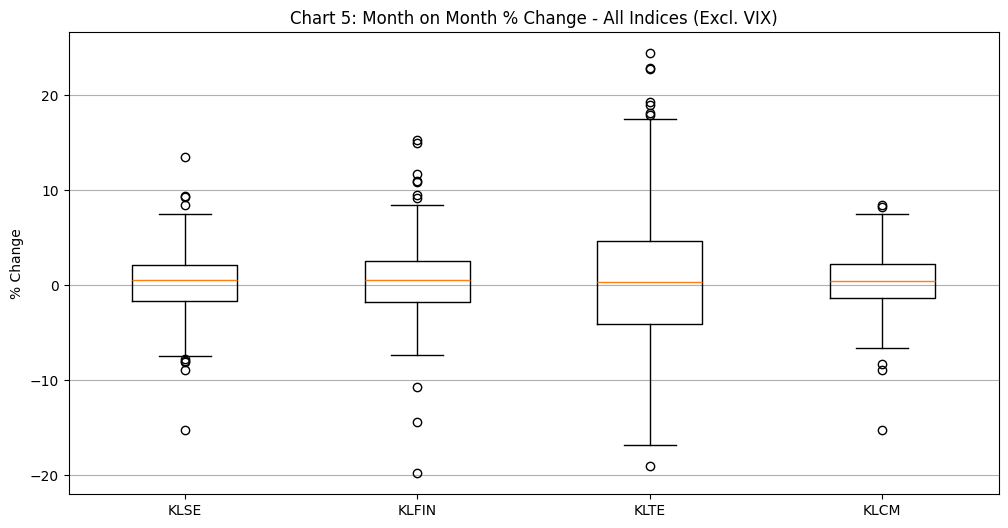

In [31]:
import matplotlib.pyplot as plt

names = [name for name in dataframe.keys() if name != 'vix']
data = [combined_change[f'{name}_% change'].dropna() for name in names]
labels = [name.upper() for name in names]

plt.figure(figsize=(12, 6))
plt.boxplot(data, tick_labels=labels, vert=True)
plt.title("Chart 5: Month on Month % Change - All Indices (Excl. VIX)")
plt.ylabel("% Change")
plt.grid(True, axis='y')
plt.show()

## 3.0 Nature of investment returns during crisis episodes

In section 2, the analysis was conducted on overall returns throughout the entirety of the time series. To extend the assessment, this section will cover the nature of investment returns during crisis episodes, which have demonstrated a significant relationship to investment returns.

For the purposes of this project, events in 2008-2009 and 2020 will be studied, as they mark the sharpest increase in VIX over the time period. The spike in 2008-2009 relates to the Great Financing Crisis when most economies experienced a banking crisis while 2020 refers to Covid-19, when economic activity significantly slowed down amid a global health pandemic.





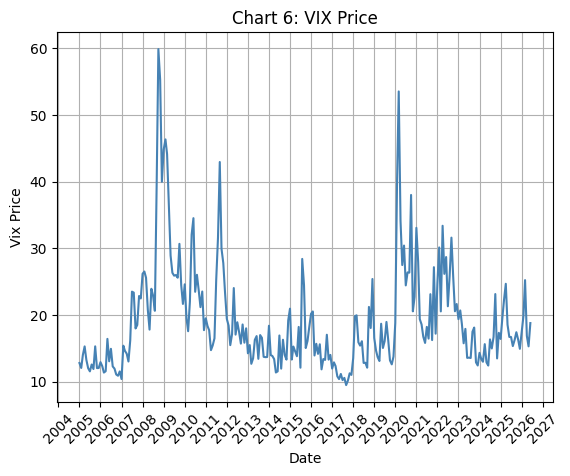

In [21]:
#Plotting VIX as a standalone line chart

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.plot("Date", "vix_price", data=combined, color='steelblue')
plt.title("Chart 6: VIX Price")
plt.xlabel("Date")
plt.ylabel("Vix Price")
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.show()

## 3.1 Correlation analysis

Over the entire series, as represented by Heatmap 1, KLSE, KLFIN and KLCM have strong co-movement with each other while KLTEC has lower correlation (i.e. less than 0.5) with the other indices. This implies that Malaysia's technology stocks are less responsive to changes in other parts of the economy. Conversely, the strong correlation between KLSE, KLFIN and KLCM suggests the sectors' performance depend on the other sectors' outcome to a certain extent:

1. For KLSE, the co-movement with other sectors could reflect that as the headline index, it includes components of KLFIN and KLCM.
2. For KLFIN, since the finance industry depends on loan demand and repayment, the performance of other sectors may inform its own profitability.
3. For KLCM, despite consumer products being largely defensive in nature,  domestic consumption remains sensitive to broader economic confidence, even for staple goods, consumer spending power is ultimately influenced by employment and income conditions, which are shaped by the wider economy.

Additionally, there do exist some negative relationship with the VIX, suggesting higher uncertainty results in lower profits.

Notwithstanding the above, the results become more nuanced once the time periods are broken down into crisis and non-crisis periods. Crisis episodes are defined as the GFC (2008-2009) period and Covid-19 (2020) while non-crisis refers to 2012-2014, where the Vix in Chart 6 shows smaller variation, suggesting uncertainties were not as high compared to GFC and Covid-19.

Heatmap 2, 3 and 4 highlight the results. Similar to the overall period, KLSE, KLFIN and KLCM maintain strong correlation across both crisis and non-crisis periods. Notably, while KLTE shows weaker correlation during non-crisis periods, this changes during crisis episodes, particularly during the GFC, where KLTE's correlation with KLSE and KLFIN rises to 0.81 and 0.86 respectively, suggesting that during severe market stress, even the technology sector is not immune to broad market movements.



References:

1. Impact of Covid-19: Evidence from Malaysian Stock Market,International Journal of Business and Society, Vol. 21 No. 2, 2020, 607-628 by Kelvin Yong-Ming Lee, Mohamad Jais and Chia-Wen Chan https://www.researchgate.net/publication/343189801_Impact_of_Covid-19_Evidence_from_Malaysian_Stock_Market

2. Stock market volatility during the 2008 Financial Crisis, Stern School of Business, 2010, Kiran Manda https://web-docs.stern.nyu.edu/glucksman/docs/Manda2010.pdf

3. Quantile connectedness between VIX and global stock markets, Borsa Istanbul Review, Volume 24, Supplement 1, October 2024, Pages 71-79  by Buket Kirci Altinkeski, Sel Dibooglu, Emrah Ismail Cevik, Yunus Kilic and Mehmet Fatih Bugan https://www.sciencedirect.com/science/article/pii/S2214845024001121


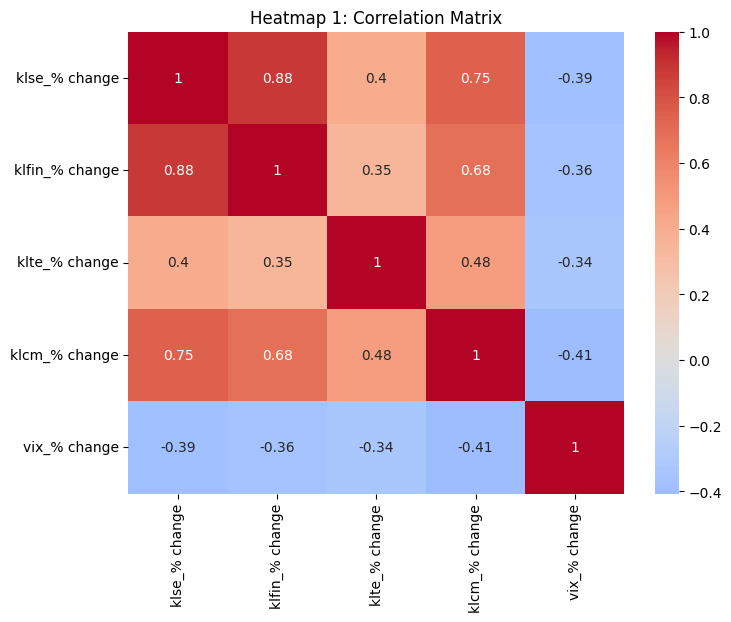

In [22]:
#Overall correlation matrix

import seaborn as sns

cols = [f'{name}_% change' for name in dataframe.keys()]
corr_matrix = combined_change[cols].dropna().corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Heatmap 1: Correlation Matrix")
plt.show()

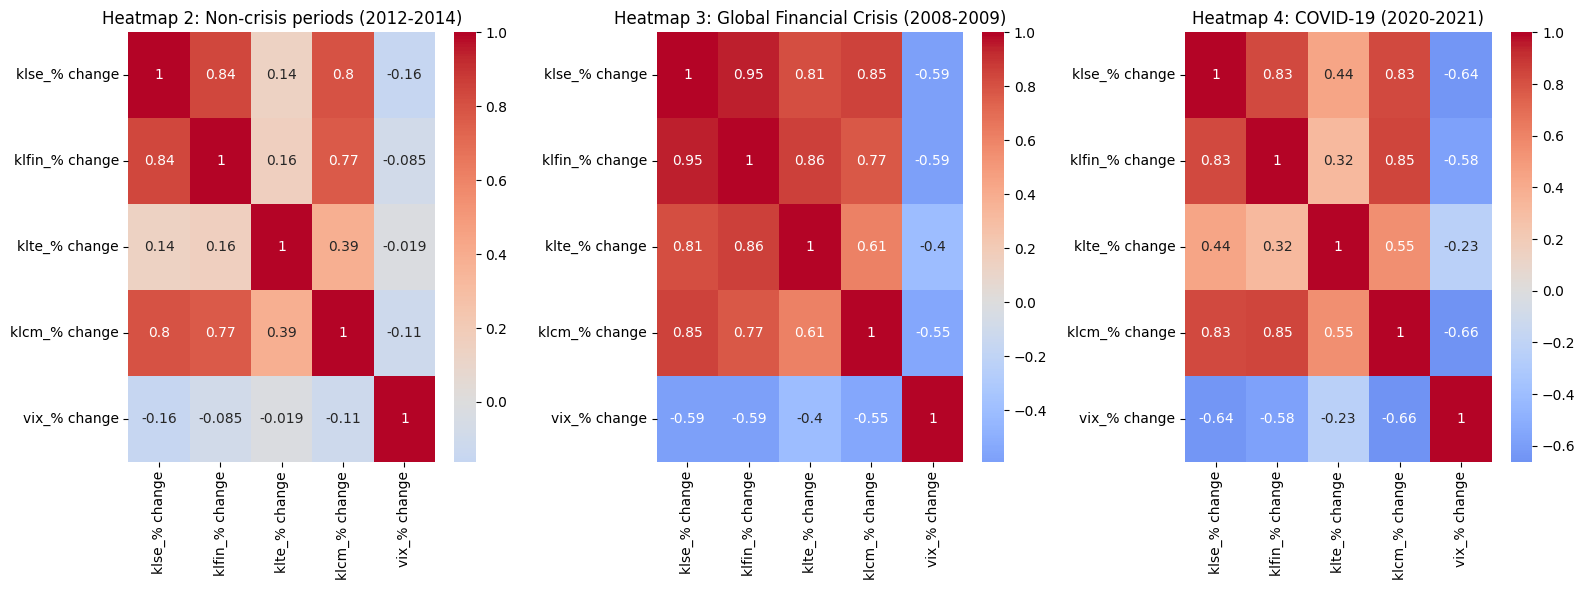

In [23]:
#Correlation during crisis period

import seaborn as sns
import matplotlib.pyplot as plt

cols = [f'{name}_% change' for name in dataframe.keys()]

# Defining crisis periods
periods = {
    "Heatmap 2: Non-crisis periods (2012-2014)": ("2012-01-01", "2014-12-01"),
    "Heatmap 3: Global Financial Crisis (2008-2009)": ("2008-01-01", "2009-12-31"),
    "Heatmap 4: COVID-19 (2020-2021)": ("2020-01-01", "2021-12-31")
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, (label, (start, end)) in enumerate(periods.items()):
    mask = (combined['Date'] >= start) & (combined['Date'] <= end)
    subset = combined_change.loc[mask, cols].dropna()
    corr_matrix = subset.corr()

    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[i])
    axes[i].set_title(label)

plt.tight_layout()
plt.show()

## 3.3 Analysing length and degree of asset price recovery from the GFC

Based on literature, the GFC was estimated to have started during early 2007, when home sales in the U.S saw its largest single-year drop in years, resulting in the bankruptcy of five subprime lending firms. According to the Reserve Bank of Australia, it peaked during September 2008, with the collapse of Lehman Brothers, one of the largest lending institutions in the U.S. This collapse led to a sharp decline in sentiments, leading to a global selloff in assets, especially equities.

These events are observed in the VIX chart below, where VIX gradually increased in early 2007. With the collapse of Lehman Brothers, VIX spiked in October 2008, one month after the event occured. Given the increasingly integratred nature of global financial markets, the concern of contagion risks from the crash in the U.S markets prompted investors to rebalance their global portfolios, including in Malaysia. This can be observed across the Malaysian stock market indices where KLSE, KLFIN, KLCM and KLTE and dropped in October 2008, after the collapse of Lehman Brothers. However, from the graph, the path to recovery among these assets differ.

For KLSE and KLFIN, the indices experienced a sharp drop and stabilised until April 2009, before recovering thereafter. For KLTE, the index was on a downward trend since May 2007, shortly after the start of the GFC, but recovered around the same time with KLSE and KLFIN. This reflects the softening global technology cycle at the time, as global technology demand readjusts itself following higher growth in previous years. As a result, the performance of Malaysia's technology sector softens, leading to a decline in the KLTE, which was then exacerbated by the GFC. On the other hand, KLCM, the consumer market index experienced a relatively soft decline in October 2008, the same as the other indices but recovered from November onwards. This reflects the defensive nature of the index, as the demand for consumer goods are inelastic, meaning they are less responsive to swings in demand. This results in earnings predictability and stability, an important criteria for investors during crisis episodes.




## Sources
1. https://www.rba.gov.au/education/resources/explainers/the-global-financial-crisis.html
2. https://www.cfr.org/articles/us-financial-crisis
3. https://www.chiphistory.org/720-the-dram-crash-of-2008
4. https://www.regions.com/-/media/pdfs/AssetManagement-The-Semiconductor-Cycle.pdf
5. https://muse.jhu.edu/pub/70/article/257249
https://gridoasis.com/guides/sector-analysis/cyclical-vs-defensive/



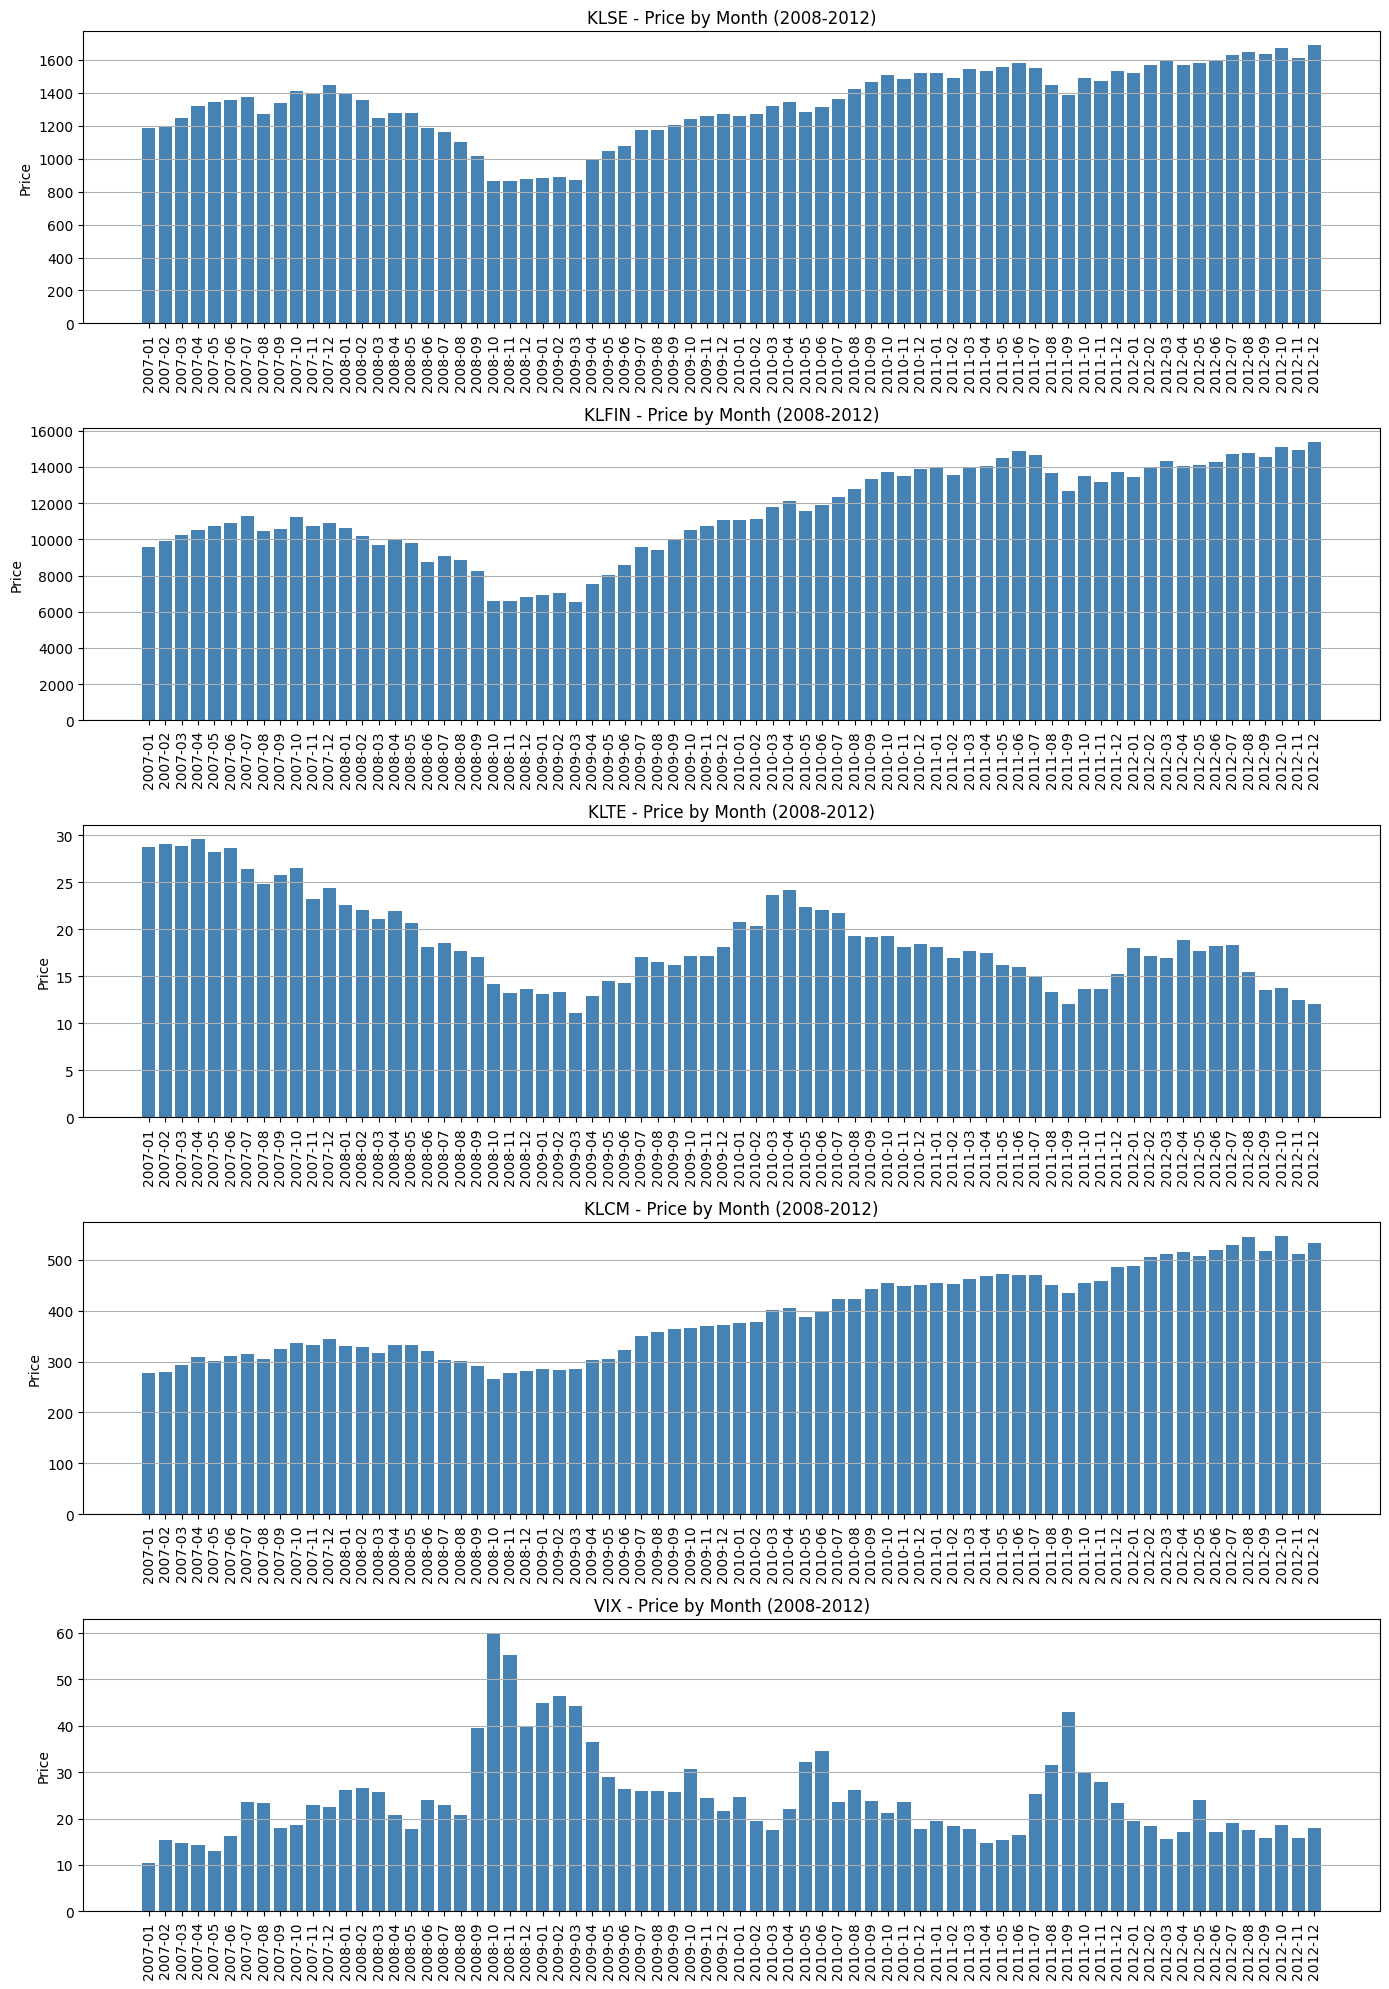

In [24]:
# Trend post GFC
import matplotlib.pyplot as plt
import pandas as pd

names = list(dataframe.keys())

gfc_mask = combined['Date'].dt.year.isin([2007,2008, 2009, 2010, 2011, 2012])
gfc_data = combined.loc[gfc_mask].copy()
gfc_data['YearMonth'] = gfc_data['Date'].dt.to_period('M').astype(str)

fig, axes = plt.subplots(len(names), 1, figsize=(14, 4*len(names)))

for i, name in enumerate(names):
    col = f'{name}_price'
    monthly = gfc_data.groupby('YearMonth')[col].mean()

    axes[i].bar(monthly.index, monthly.values, color='steelblue')
    axes[i].set_title(f"{name.upper()} - Price by Month (2008-2012)")
    axes[i].set_ylabel("Price")
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].grid(True, axis='y')

plt.tight_layout()
plt.show()

## 3.4 Analysing the length and degree of asset price recovery post-COVID19

Similar to GFC, the COVID-19 pandemic presented a shock to the global economy, where mobility restrictions resulted in slowing economic activity. Heightening uncertainty was observed in VIX in March 2020, when Governments around the world began implementing lockdowns. This had a contemporaneous effect on all the indices, as KLSE, KLFIN, KLCM and KLTE all dropped in March 2020. However, compared to GFC in 2008-2009, most indices began recovering one month after the shock, apart from KLFIN.

Broad recovery in KLSE and KLCM likely reflects the Government's stimulus packages to encourage spending and lift the economy, which bodes well for investors. However, earnings for KLFIN were likely affected by reduced overnight policy rates (OPR) and continued moratorium, as policy makers continued expansionary measures to support Malaysians during the pandemic.

For KLTE, the sector benefitted from exemptions to movement restrictions, allowing some production to continue, enabling them to continue generating earnings for investors. Additionally, the sector benefitted from a global technology upcycle following increased demands for electronics as businesses adopt a hybrid working environment to adapt to COVID restrictions

Source:

1. https://www.trendforce.com/presscenter/news/20210602-10816.html
2. https://www.bnm.gov.my/-/monetary-policy-statement-03032020
3. https://www.bnm.gov.my/-/monetary-policy-statement-05052020
4. https://jurcon.ums.edu.my/ojums/index.php/lbibf/article/view/3318/2369
5. https://www.fsmone.com.my/article/226262/malaysia-sector-outlook-tech-to-ride-on-the-semiconductor-upcycle

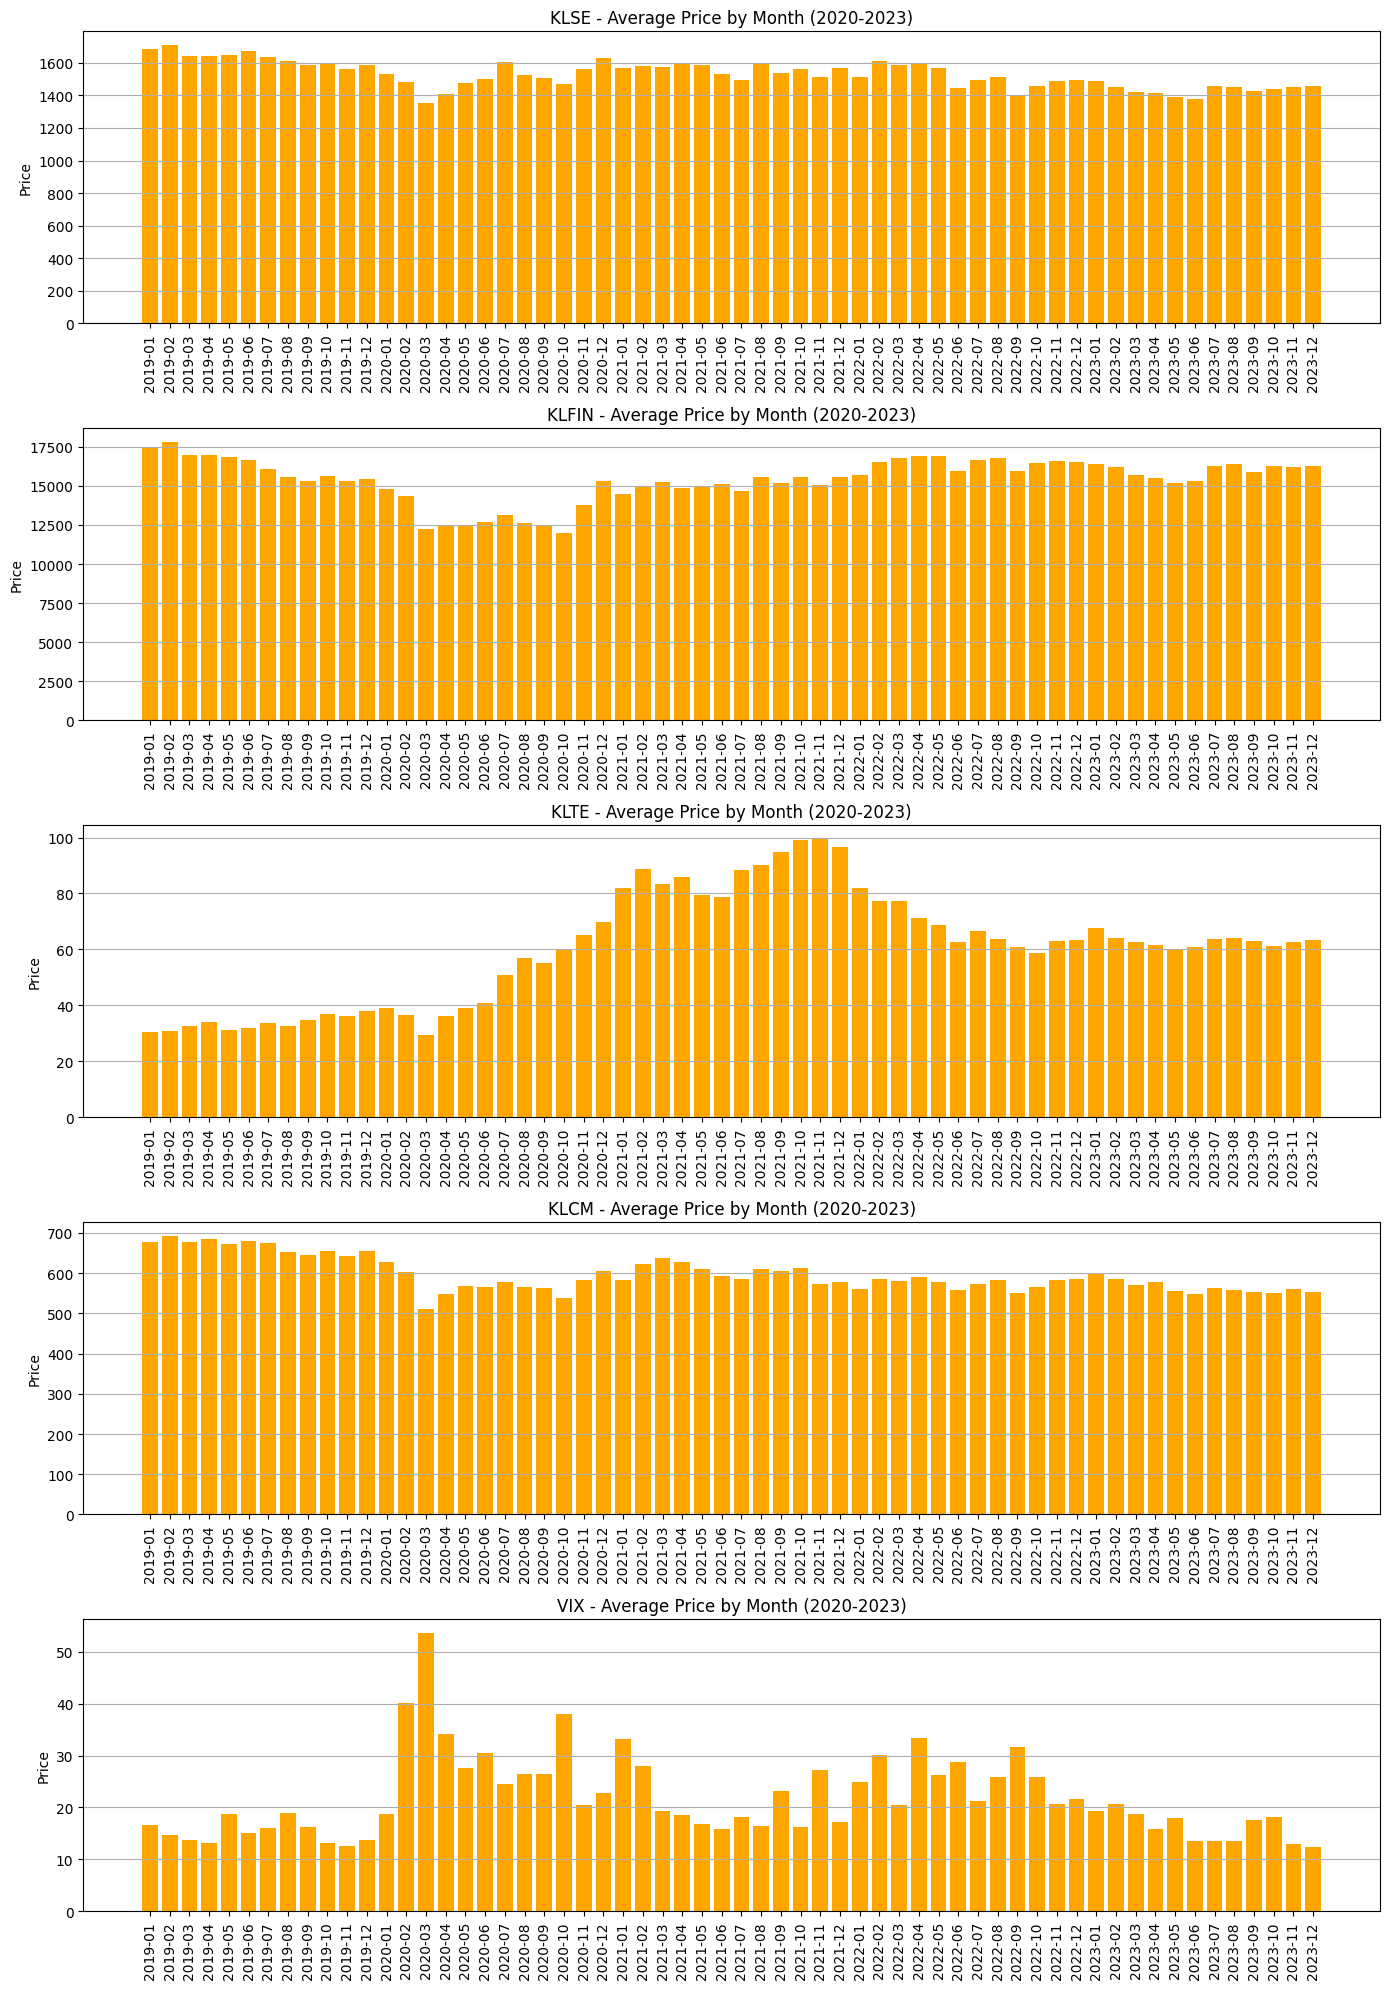

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

names = list(dataframe.keys())

covid_mask = combined['Date'].dt.year.isin([2019, 2020, 2021, 2022, 2023])
covid_data = combined.loc[covid_mask].copy()
covid_data['YearMonth'] = covid_data['Date'].dt.to_period('M').astype(str)

fig, axes = plt.subplots(len(names), 1, figsize=(14, 4*len(names)))

for i, name in enumerate(names):
    col = f'{name}_price'
    monthly = covid_data.groupby('YearMonth')[col].mean()

    axes[i].bar(monthly.index, monthly.values, color='orange')
    axes[i].set_title(f"{name.upper()} - Average Price by Month (2020-2023)")
    axes[i].set_ylabel("Price")
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].grid(True, axis='y')

plt.tight_layout()
plt.show()

## 3.5 Significance of sentiments (VIX) in explaining asset returns

Based on the scatter plots below, all indices show an inverse relationship with VIX i.e. higher uncertainty (VIX) leads to lower month-on-month returns, and vice versa.  Increasing uncertainty results in higher risk aversion among investors, prompting them to divert their assets from stocks to other safer assets e.g. bonds, gold or cash. These results confirm earlier discussions and findings by other published authors.

Additionally, based on the regression tables, the consumer index (KLCM) has the lowest responsiveness to VIX. In other words, an additional 1 percentage point (ppt) change in Vix results in lower KLCM retuns by 0.052 ppt, compared to KLSE (0.053ppt), KLFIN (0.058ppt) and KLTE (0.10ppt). As expected, KLTE and KLFIN are more responsive given they are cyclical sectors, compared to KLCM which is more defensive. Statistically significant results (p value less than 0.05) implies that uncertainty is a good factor explaining investment returns. However, since the reported R-squared across all sectors are low (i.e. all results are less than 0.2 suggesting Vix explains less than 20% of movements), there could be other drivers for each individual index's returns.



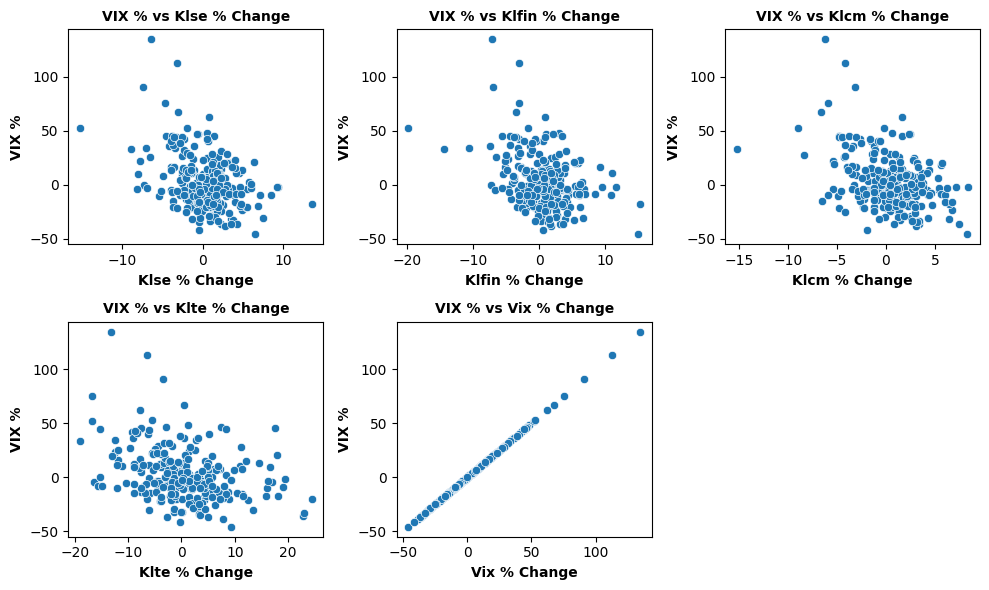

In [26]:
import seaborn as sns
# Define significant variable (sig_var) with the required columns
sig_var = combined_change[[
    'klse_% change', 'klfin_% change', 'klcm_% change', 'klte_% change', 'vix_% change'
]].copy()

# List of variables to plot
variables = ['klse_% change', 'klfin_% change', 'klcm_% change', 'klte_% change', 'vix_% change']

# Setting the grid for subplots (2 rows x 3 columns)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 6))

# Flatten axes for easier iteration
axes = axes.flatten()

# Loop through variables and create scatter plots
for i, var in enumerate(variables):
    sns.scatterplot(data=sig_var, x=var, y='vix_% change', ax=axes[i])
    axes[i].set_title(f'VIX % vs {var.replace("_", " ").title()}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(var.replace("_", " ").title(), fontweight='bold')
    axes[i].set_ylabel("VIX %", fontweight='bold')

# Hide any unused subplots
for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

In [27]:
#OLS for VIX and indicators

import statsmodels.api as sm
import pandas as pd

names = [n for n in dataframe.keys() if n != "vix"]

results = []
for name in names:
    df = combined_change[['vix_% change', f'{name}_% change']].dropna()
    X = sm.add_constant(df['vix_% change'])
    y = df[f'{name}_% change']
    model = sm.OLS(y, X).fit()
    results.append({
        'Index': name.upper(),
        'Coef (VIX)': model.params['vix_% change'],
        'p-value': model.pvalues['vix_% change'],
        'R-squared': model.rsquared
    })
    print(f"=== {name.upper()} ~ VIX ===")
    print(model.summary())
    print("\n")

pd.DataFrame(results)

=== KLSE ~ VIX ===
                            OLS Regression Results                            
Dep. Variable:          klse_% change   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     45.00
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           1.25e-10
Time:                        07:38:39   Log-Likelihood:                -656.49
No. Observations:                 258   AIC:                             1317.
Df Residuals:                     256   BIC:                             1324.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.4398      

,Index,Coef (VIX),p-value,R-squared
0,KLSE,-0.052868,1.254197e-10,0.149514
1,KLFIN,-0.058333,2.095382e-09,0.131023
2,KLTE,-0.103265,2.870196e-08,0.113540
3,KLCM,-0.052313,1.015105e-11,0.165735


## 4.0 Conclusion

This project has provided insights into the behaviour of returns in the Malaysian stock market. The outcomes from this project highlights the nature of investments i.e. higher risk sectors can expect greater returns as well as losses.

Additionally, the correlation tables highlight that some sectors co-move with each other during crisis episodes, suggesting investors should expect their investment holdings to be affected. However, the nuance is that the investor could be shielded depending on whether the industry is non-cyclical or is expected to benefit from strong underlying demand such as the global technology upcycle.

Separately, uncertainty as measured by VIX plays a role in determining investment returns, as represented by the statistical significance with all the Malaysian stock indices.